Make sure acc_comp is the same

### 1. Dependencies

In [52]:
#import wrds
import datetime
import numpy as np
import pandas as pd
from itertools import chain
import seaborn as sns
import matplotlib.pyplot as plt
import wrds

# Set LaTeX rendering for legend entries
plt.rcParams['text.usetex'] = False

def standardize_df_rows(df):
    return df.sub(df.mean(axis=1), axis=0).div(df.std(axis=1), axis=0)

In [53]:

def compute_weighted_average(returns, raw_weights, permnos):
    """
    Compute the weighted average of the returns for a specified subset of permnos.
    """
    
    # Get data corresponding to `permno`
    returns_selection = returns[permnos]
    raw_weights_selection = raw_weights[permnos]

    # Skip missing data in `returns_selection`
    raw_weights_selection[returns_selection.isna()] = np.nan
    
    # Compute standardised weights
    weights_selection = raw_weights_selection/raw_weights_selection.sum()

    # Compute and return weighted average of the returns
    return (returns_selection * weights_selection).sum()



def univariate_portfolio_sorting(series_1, no_quantiles_1):
    """
    Univariate portfolio sorting. 
    """
    # Pre-allocate memory for output
    output = pd.Series(name=series_1.name, dtype=float)

    # Construct quantile numpy array
    quantiles_1 = series_1.quantile(np.linspace(1/no_quantiles_1, 1, num=no_quantiles_1))

    # Loop over quantiles
    for i in range(no_quantiles_1):

        # Sorting on `series_1`
        in_slice = series_1 <= quantiles_1.iloc[i]
        if i > 0:
            in_slice &= series_1 > quantiles_1.iloc[i-1]
        
        # Update output accordingly
        output[f"p_{i+1}"] = series_1[in_slice].index
    
    # Return output
    return output


def double_portfolio_sorting(series_1, series_2, no_quantiles_1, no_quantiles_2):
    """
    Double portfolio sorting. 
    """ 
    # Pre-allocate memory for output
    output = pd.Series(name=series_1.name, dtype=float)

    # Construct quantile numpy arrays
    quantiles_1 = series_1.quantile(np.linspace(1/no_quantiles_1, 1, num=no_quantiles_1))
    quantiles_2 = series_2.quantile(np.linspace(1/no_quantiles_2, 1, num=no_quantiles_2))

    # Loop over quantiles
    for i in range(no_quantiles_1):
        for j in range(no_quantiles_2):
                
            # Sorting on `series_1` and `series_2`
            in_slice = series_1 <= quantiles_1.iloc[i]
            in_slice &= series_2 <= quantiles_2.iloc[j]
            if i > 0:
                in_slice &= series_1 > quantiles_1.iloc[i-1]
            if j > 0:
                in_slice &= series_2 > quantiles_2.iloc[j-1]

            # Update output accordingly
            output[f"p_{i+1}_{j+1}"] = series_1[in_slice].index
        
    # Return output
    return output


def double_portfolio_sorting_ext(series_1, series_2, no_quantiles_1, no_quantiles_2):
    """
    Double portfolio sorting (return quantile pairs as well as regular output).
    """
    # Pre-allocate memory for output
    output = pd.Series(name=series_1.name, dtype=float)
    pairs = pd.DataFrame(index=[series_1.name])

    # Construct quantile numpy arrays
    quantiles_1 = series_1.quantile(np.linspace(1/no_quantiles_1, 1, num=no_quantiles_1))
    quantiles_2 = series_2.quantile(np.linspace(1/no_quantiles_2, 1, num=no_quantiles_2))

    # Loop over quantiles
    for i in range(no_quantiles_1):
        for j in range(no_quantiles_2):
                
            # Sorting on `series_1` and `series_2`
            in_slice = series_1 <= quantiles_1.iloc[i]
            in_slice &= series_2 <= quantiles_2.iloc[j]
            if i > 0:
                in_slice &= series_1 > quantiles_1.iloc[i-1]
            if j > 0:
                in_slice &= series_2 > quantiles_2.iloc[j-1]

            # Update output accordingly
            output[f"p_{i+1}_{j+1}"] = series_1[in_slice].index

            # Update additional output
            pairs.loc[:, f"p_{i+1}_{j+1}_s1"] = series_1[in_slice].mean() 
            pairs.loc[:, f"p_{i+1}_{j+1}_s2"] = series_2[in_slice].mean()
    
    # Return output
    return output, pairs


def get_df_quantiles(df, no_quantiles):
    """
    Get quantiles' rank of `df`
    """
    # Compute data quantiles
    quantiles = df.quantile(np.linspace(1/no_quantiles, 1, num=no_quantiles), axis=1).transpose()

    # Pre-allocate memory for output
    df_quantiles = pd.DataFrame(0.0, index=df.index, columns=df.columns)
    for i in range(no_quantiles):
        df_quantiles += df.le(quantiles.values[:, i], axis=0).astype(float)

    # Put back nans where appropriate
    df_quantiles[df.isna()] = np.nan

    # Return output
    return df_quantiles

### 2. Data

#### 2.1 LC dataset

In [54]:
DATA_PATH = "C:/Users/chris/Documents/GitHub/Finance_Lab_Data"

In [55]:
# Load full dataset --- was originally LC_dataset_v_1_1L (not master)
lc = pd.read_parquet(f'{DATA_PATH}/LC_dataset_v_1_1L_master.parquet')

# Change types to align with WRDS
lc['gvkey'] = lc['gvkey'].astype(int).astype(str)
lc['rfyear'] = lc['rfyear'].astype(int)

# Keep rows with some minimum information
lc = lc.dropna(subset=['gvkey', 'rfyear', 'loc', 'MacroRegion', 'GICS_level_1', 'GICS_level_2', 'GICS_level_3'])

# Filter rows where MacroRegion is in the specified list
regions = ["Asia-Pacific", "Europe", "United States and Canada"]
lc = lc[lc['MacroRegion'].isin(regions)]

# Filter data to keep observatios from 2009
lc = lc[lc['rfyear'] >= 2009]

# Merge `Real Estate` and `Financial`
lc.loc[lc['GICS_level_1'] == 'Real Estate', 'GICS_level_1'] = 'Financial'

"""
# Filter data to drop Financial and RE
lc = lc[~lc['GICS_level_1'].isin(['Financial', 'Real Estate'])]

# Filter to keep a stable panel
gvkey_stable_panel = lc.groupby(['gvkey'])['gvkey'].count() == (lc['rfyear'].max()-lc['rfyear'].min()+1)
gvkey_stable_panel = gvkey_stable_panel[gvkey_stable_panel].index
lc = lc[lc['gvkey'].isin(gvkey_stable_panel)]
"""

"\n# Filter data to drop Financial and RE\nlc = lc[~lc['GICS_level_1'].isin(['Financial', 'Real Estate'])]\n\n# Filter to keep a stable panel\ngvkey_stable_panel = lc.groupby(['gvkey'])['gvkey'].count() == (lc['rfyear'].max()-lc['rfyear'].min()+1)\ngvkey_stable_panel = gvkey_stable_panel[gvkey_stable_panel].index\nlc = lc[lc['gvkey'].isin(gvkey_stable_panel)]\n"

In [56]:
lc.loc[lc['loc'] == 'USA', 'gvkey'].unique().shape

(2178,)

In [57]:
def map_sectors(x): # Note: Health Care is not aggregated further, Real Estate includes mostly developers which are closer to other hard-to-abate sectors, NOT FINANCIALS
    if x in ['Financial']:
        return 'Financial'
    elif x in ['Consumer Discretionary', 'Consumer Staples']:
        return 'Consumer goods'
    elif x in ['Materials', 'Industrials','Real Estate']:
        return 'Industrial goods'
    elif x in ['Energy', 'Utilities']:
        return 'Energy'
    elif x in ['Communication Services', 'Information Technology']:
        return 'Technology'
    return x

lc['Industry'] = lc['GICS_level_1'].apply(map_sectors)

In [58]:
'''
Dictionary specifying types categories

Stakeholders:
  - customers
  - employees
  - enviroment
  - local communities and society
  - nothing
  - shareholders
  - suppliers
'''

# Actions
categories_dict_actions = {
  'philanthropy, internal changes, org transformation':
    {
      # 'TYPE: association': 0, 
      # 'TYPE: pricing': 2,                                                             # For our universe, these are usually discounts to disadvantaged customers
      'TYPE: donation & funding': 0, 
      'TYPE: volunteerism': 0, 
      'TYPE_SREC: communication - local communities and society': 0, 
      'TYPE_SREC: incentives - local communities and society': 0,                     # For our universe, these are usually `donation & funding` through vouchers etc.
      'TYPE_SREC: training - local communities and society': 0,                       # For our universe, these are usually akin to volunteering activities
      'TYPE_SREC: modification of procedures - local communities and society': 0, 
      
      'TYPE: adoption of standards and rules': 1, 
      'TYPE: assessment and measurement': 1,                                          # For our universe, these are mostly partnerships (e.g., with ONGs) for enviromental/social impact assessments
      'TYPE: organizational structuring': 1,                                          # For our universe, these relate with HR initiatives - particularly, investments in employee resource groups and partnerships
      'TYPE_SREC: communication - employees': 1, 
      'TYPE_SREC: training - employees': 1, 
      'TYPE_SREC: incentives - employees': 1, 
      'TYPE_SREC: modification of procedures - employees': 1, 
      
      'TYPE: asset modification': 2,
      'TYPE: new products': 2, 
      'TYPE: r&d investments': 2, 
      'TYPE_SREC: communication - customers': 2, 
      'TYPE_SREC: communication - suppliers': 2, 
      'TYPE_SREC: training - customers': 2, 
      'TYPE_SREC: training - suppliers': 2, 
      'TYPE_SREC: incentives - customers': 2, 
      'TYPE_SREC: incentives - suppliers': 2, 
      'TYPE_SREC: modification of procedures - customers': 2, 
      'TYPE_SREC: modification of procedures - suppliers': 2, 
  },
}

# MANUAL INPUT
# Choose which action characterization to use
categories_dict_actions = categories_dict_actions['philanthropy, internal changes, org transformation']

In [59]:
"""
# People vs Planet SDGs
categories_dict_sdgs = {
  'SDG: 1': 0,
  'SDG: 2': 0,
  'SDG: 3': 0,
  'SDG: 4': 0,
  'SDG: 5': 0,
  'SDG: 8': 0,
  'SDG: 10': 0,
  'SDG: 6': 1,
  'SDG: 7': 1,
  'SDG: 12': 1,
  'SDG: 13': 1,
  'SDG: 14': 1,
  'SDG: 15': 1
}

# Initialise dictionary
categories_dict_people = {}
categories_dict_planet = {}

# Initialise other dictionaries
categories_dict_people_advocacy = {}
categories_dict_planet_advocacy = {}

# Loop over actions
for key_action, value_action in categories_dict_actions.items():

    # Loop over sdgs
    for key_sdg, value_sdg in categories_dict_sdgs.items():
        
        # Planet-related activities
        if value_sdg == 1:
            categories_dict_planet[f'{key_action.replace("TYPE: ", "").lower()} - {key_sdg.replace(":", "")}'] = value_action
            categories_dict_planet_advocacy[f'{key_action.replace("TYPE: ", "").lower()} - {key_sdg.replace(":", "")}'] = 2-value_action
            
        else:
            categories_dict_people[f'{key_action.replace("TYPE: ", "").lower()} - {key_sdg.replace(":", "")}'] = value_action
            categories_dict_people_advocacy[f'{key_action.replace("TYPE: ", "").lower()} - {key_sdg.replace(":", "")}'] = 2-value_action
"""

'\n# People vs Planet SDGs\ncategories_dict_sdgs = {\n  \'SDG: 1\': 0,\n  \'SDG: 2\': 0,\n  \'SDG: 3\': 0,\n  \'SDG: 4\': 0,\n  \'SDG: 5\': 0,\n  \'SDG: 8\': 0,\n  \'SDG: 10\': 0,\n  \'SDG: 6\': 1,\n  \'SDG: 7\': 1,\n  \'SDG: 12\': 1,\n  \'SDG: 13\': 1,\n  \'SDG: 14\': 1,\n  \'SDG: 15\': 1\n}\n\n# Initialise dictionary\ncategories_dict_people = {}\ncategories_dict_planet = {}\n\n# Initialise other dictionaries\ncategories_dict_people_advocacy = {}\ncategories_dict_planet_advocacy = {}\n\n# Loop over actions\nfor key_action, value_action in categories_dict_actions.items():\n\n    # Loop over sdgs\n    for key_sdg, value_sdg in categories_dict_sdgs.items():\n\n        # Planet-related activities\n        if value_sdg == 1:\n            categories_dict_planet[f\'{key_action.replace("TYPE: ", "").lower()} - {key_sdg.replace(":", "")}\'] = value_action\n            categories_dict_planet_advocacy[f\'{key_action.replace("TYPE: ", "").lower()} - {key_sdg.replace(":", "")}\'] = 2-value_action\

In [60]:
# MANUAL INPUT
categories_dict = categories_dict_actions
plt_title_suffix = 'Transformation'
plt_max_to_min_title_suffix = 'Transformation to advocacy'

# FIND MIN AND MAX CATEGORY ID
min_category = min(categories_dict.values())
max_category = max(categories_dict.values())

In [61]:
for (key, value) in categories_dict.items():
    if f'sum_with_{value}' in lc.columns:
        lc[f'sum_with_{value}'] += lc[key]
    else:
        lc[f'sum_with_{value}'] = lc[key].values

lc['sum_activities'] = lc.loc[:, list(categories_dict.keys())].sum(axis=1)

In [62]:
for i in range(max_category+1):
    lc[f'signal_{i}'] = lc[f'sum_with_{i}'] / lc['sum_activities']

#### 2.2 WRDS and TRUCOST data

In [63]:
# MANUAL INPUT
download_wrds_data = False

In [64]:
###################
# Connect to WRDS #
###################

if download_wrds_data:
    conn=wrds.Connection()

##### 2.2.1 Recover dollar returns from Compustat

From WRDS tutorials:

To compute returns, you will need to apply a DAILY RETURN FACTOR (variable TRFD) to the close price. 
That is, multiplying the current adjusted close price (PRCCD/AJEXDI) by the current total return factor (TRFD)
and dividing the result by the product of the adjusted close price of the prior period multiplied by the 
Total Return Factor of the prior period.

In other words:
1. Adjust the close price for corporate actions
2. Compute the close price + dividends by multiplying PRCCD/AJEXDI for TRFD
3. Compute daily returns

This can be aggregated to compute monthly figures.

In [65]:
# Download from WRDS
if download_wrds_data:

    usa_universe = conn.raw_sql("""
        WITH 
            usa_listings AS (
                SELECT gvkey, priusa
                FROM comp.company
                WHERE priusa IS NOT NULL
            )
        
        SELECT 
            secd.datadate AS date, 
            secd.gvkey, 
            secd.iid, 
            (secd.prccd * secd.cshoc) as mktcap, 
            CASE WHEN secd.ajexdi <> 0 THEN (secd.trfd * secd.prccd / secd.ajexdi) ELSE NULL END AS tri
        FROM 
            comp.secd AS secd
        JOIN
            usa_listings
            ON (secd.gvkey=usa_listings.gvkey AND secd.iid=usa_listings.priusa)
        WHERE
            (secd.datadate BETWEEN '01/01/2009' AND '12/31/2022')
            AND (secd.secstat='A')
            AND (secd.tpci='0')
            AND (secd.prccd>0)
            AND (secd.cshtrd>0)
            AND (secd.exchg IN (11, 12, 14))
        ORDER BY 
            date;
    """, date_cols=['date'])

    # Keep entries with non-missing total return index
    usa_universe = usa_universe[usa_universe['tri'].notna()].reset_index(drop=True)
    
    # Save to disk
    print('Saving to disk!')
    usa_universe.to_csv('./data/usa_universe.csv')

# Load from file
else:
    usa_universe = pd.read_csv('./data/usa_universe.csv').iloc[:, 1:]

# Set dates to datetime format
usa_universe['date'] = pd.to_datetime(usa_universe['date'])
usa_universe['gvkey'] = usa_universe['gvkey'].astype(float).astype(str)

# Add column to indicate that the LCU is US dollars
usa_universe['curcdd'] = 'USD'

FileNotFoundError: [Errno 2] No such file or directory: './data/usa_universe.csv'

In [66]:
# Download from FRB H.10
# https://www.federalreserve.gov/datadownload/Output.aspx?rel=H10&series=d3efeda92e22923be9b7c3d7250706ac&lastobs=&from=01/01/2009&to=12/31/2022&filetype=csv&label=include&layout=seriescolumn

# Load exchange rate data
FRB_H10 = pd.read_csv(f'{DATA_PATH}/FRB_H10.csv')
FRB_H10.replace('ND', np.nan, inplace=True)
FRB_H10.columns = ['date', 'EUR', 'GBP', 'DKK', 'NOK', 'SEK', 'CHF']

# Take inverse of the following exchange rates to have them all expressed as per USD
FRB_H10_take_inverse = FRB_H10.iloc[2, :] == 'USD'

# Foreign exchange rate data
fx_rates = FRB_H10.iloc[5:]

# Set rates to float
fx_rates.iloc[:, 1:] = fx_rates.iloc[:, 1:].astype(float)

# Invert exchange rate where needed
fx_rates.loc[:, FRB_H10_take_inverse] = 1/fx_rates.loc[:, FRB_H10_take_inverse].values

# Forward-fill fx rates (in levels)
fx_rates = fx_rates.ffill(axis=0)

# Convert to long format
fx_rates = fx_rates.melt(id_vars=['date'], var_name='curcdd', value_name='rate')

# Set dates to datetime format
fx_rates['date'] = pd.to_datetime(fx_rates['date'])

C:\Users\chris\AppData\Local\Temp\ipykernel_32056\1068915767.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fx_rates.iloc[:, 1:] = fx_rates.iloc[:, 1:].astype(float)
C:\Users\chris\AppData\Local\Temp\ipykernel_32056\1068915767.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fx_rates.loc[:, FRB_H10_take_inverse] = 1/fx_rates.loc[:, FRB_H10_take_inverse].values
C:\Users\chris\AppData\Local\Temp\ipykernel_32056\1068915767.py:22: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to 

In [67]:
# Download from WRDS
if download_wrds_data:

    row_universe = conn.raw_sql("""
        WITH 
            row_listings AS (
                SELECT gvkey, prirow
                FROM comp.g_company
                WHERE prirow IS NOT NULL
            )
        
        SELECT 
            g_secd.datadate AS date, 
            g_secd.gvkey, 
            g_secd.iid, 
            g_secd.curcdd, 
            (g_secd.prccd * g_secd.cshoc / g_secd.qunit) as mktcap_lcu, 
            CASE WHEN g_secd.ajexdi <> 0 THEN (g_secd.trfd * g_secd.prccd / (g_secd.qunit * g_secd.ajexdi)) ELSE NULL END AS tri_lcu
        FROM 
            comp.g_secd AS g_secd
        JOIN
            row_listings
            ON (g_secd.gvkey=row_listings.gvkey AND g_secd.iid=row_listings.prirow)
        WHERE
            (g_secd.datadate BETWEEN '01/01/2009' AND '12/31/2022')
            AND (g_secd.secstat='A')
            AND (g_secd.tpci='0')
            AND (g_secd.prccd>0)
            AND (g_secd.cshtrd>0)
            AND (g_secd.exchg IN (273, 132, 294, 253, 278, 221, 235, 144, 305, 261, 286, 167, 286, 154, 171, 107, 134, 237, 172, 209, 198, 271, 104, 228, 276, 192, 133, 211, 346, 333, 122, 193, 201, 256, 151, 194))
            AND (g_secd.curcdd IN ('CHF', 'GBP', 'EUR', 'DKK', 'NOK', 'SEK'))
        ORDER BY 
            date;
    """, date_cols=['date'])

    # Keep entries with non-missing total return index
    row_universe = row_universe[row_universe['tri_lcu'].notna()].reset_index(drop=True)
    
    # Save to disk
    print('Saving to disk!')
    row_universe.to_csv('./data/row_universe.csv')

# Load from file
else:
    row_universe = pd.read_csv('./data/row_universe.csv').iloc[:, 1:]

# Set dates to datetime format
row_universe['date'] = pd.to_datetime(row_universe['date'])
row_universe['gvkey'] = row_universe['gvkey'].astype(float).astype(str)

# Currency conversions
row_universe = pd.merge(row_universe, fx_rates, on=['date', 'curcdd'], how='left')
row_universe['mktcap'] = row_universe['mktcap_lcu'] / row_universe['rate']
row_universe['tri'] = row_universe['tri_lcu'] / row_universe['rate']

FileNotFoundError: [Errno 2] No such file or directory: './data/row_universe.csv'

In [ ]:
# Merge and generate global universe
global_universe = pd.concat([usa_universe, row_universe[usa_universe.columns]], axis=0)

# Drop missings in `mktcap`
global_universe = global_universe[global_universe['mktcap'].notna()]

# Add temporal identifiers
global_universe['month'] = global_universe['date'].dt.month
global_universe['year'] = global_universe['date'].dt.year

NameError: name 'usa_universe' is not defined

In [ ]:
# get accounting ratios
download_wrds_data = True
full_gvkeys = [str.zfill(gvkey, 6) for gvkey in global_universe['gvkey'].astype(float).astype(int).astype(str).unique()]
table = 'funda'
varlist = ['gvkey', 'datadate', 'ebitda', 'at', 'sale']
start_date = '2009-01-01'
end_date = '2022-12-31'
# Download from WRDS
if download_wrds_data:
    na_call = "SELECT " + ', '.join(varlist) + '\n' + "FROM comp_na_daily_all." + table + '\n'+ """
        WHERE gvkey IN %(gvkey_list)s
        AND datadate BETWEEN %(start_date)s AND %(end_date)s
        """
    compustat_na = conn.raw_sql(
        na_call,
        params={
                "gvkey_list": tuple(full_gvkeys),
                "start_date": start_date,
                "end_date": end_date}
    )
    df = pd.DataFrame(compustat_na)

    global_call = "SELECT " + ', '.join(varlist) + '\n' + "FROM comp_global_daily.g_" + table + '\n' + """     
        WHERE gvkey IN %(gvkey_list)s
       AND datadate BETWEEN %(start_date)s AND %(end_date)s
        """
    compustat_global = conn.raw_sql(
        global_call,
        params={
                "gvkey_list": tuple(full_gvkeys),
                "start_date": start_date,
                "end_date": end_date}
    )
    df2 = pd.DataFrame(compustat_global)
    dt = pd.concat([df, df2])
    dt = dt[(dt['at']>0) & (dt['sale']>0)]

    dt['roa']= dt['ebitda']/dt['at']
    dt['ros']= dt['sale']/dt['at']
    dt['year'] = pd.to_datetime(dt['datadate']).dt.year
    dt = dt.drop(columns=['ebitda', 'at', 'sale', 'datadate'])
    # Save to disk
    print('Saving to disk!')
    dt.to_csv('./data/acc_comp.csv', index=False)


else:
    dt = pd.read_csv('./data/acc_comp.csv')

dt['gvkey'] = dt['gvkey'].astype(float).astype(str)

# Merge accounting ratios
global_universe = pd.merge(global_universe, dt, on=['gvkey', 'year'], how='left')

NameError: name 'global_universe' is not defined

In [ ]:
# First, ensure the data is sorted by date within each group
global_universe_sorted = global_universe.sort_values(by=['date'])

# Use the last() function to get the last available market cap values
last_values = global_universe_sorted.groupby(['month', 'year', 'curcdd', 'gvkey', 'iid']).agg(last_mktcap=('mktcap', 'last')).reset_index()

# Sort `last_values`
last_values = last_values.sort_values(by=['month', 'year', 'curcdd', 'last_mktcap'])

# Aggregate mktcap data
last_values['cumulative_mktcap'] = last_values.groupby(['month', 'year', 'curcdd'])['last_mktcap'].cumsum()
last_values['total_mktcap'] = last_values.groupby(['month', 'year', 'curcdd'])['last_mktcap'].transform('sum')

# Merge this novel mktcap data
global_universe = pd.merge(
    global_universe, 
    last_values,
    on=['month', 'year', 'curcdd', 'gvkey', 'iid'], 
    how='left'
)

# Keep 90% of total market cap (of each currency area)
global_universe = global_universe[global_universe['cumulative_mktcap'] > 0.10*global_universe['total_mktcap']]

NameError: name 'global_universe' is not defined

In [ ]:
global_universe = global_universe[global_universe['curcdd'].isin(['EUR', 'USD'])] #['CHF', 'GBP', 'EUR', 'USD'])]

#### 2.2.2 TruCost Emission data

In [ ]:
# Import trucost emissions universe from datastream, or use partial file
global_universe['gvkey'] = global_universe['gvkey'].dropna().astype(float).astype(int).astype(str)
actual_gvkeys = global_universe['gvkey'].dropna().unique()

try:
    truc1 = pd.read_csv('./data/TruCost_0423.csv') #load piecewise Trucost data
    truc2 = pd.read_csv('./data/TruCost_1023.csv')
    truc3 = pd.read_csv('./data/TruCost_emissions_02-23_vF.csv')
    truc1 = truc1[['DirectControl','cyear','SP_ISIN']].rename(columns={'DirectControl':'direct_control'}) #keep firm-year and direct emissions
    truc2 = truc2[['2022','cyear','SP_ISIN']].rename(columns={'2022':'direct_control'})
    truc3 = truc3[['gvkey','year','scope1_abs','scope2_loc_abs','scope3_down_abs','scope3_up_abs']]
    truc = pd.concat([truc1,truc2],axis=0).rename(columns={'cyear':'year'}) #concatenate the two pieces


    isin_gvkey = pd.read_csv('./data/ISIN_GVKEY_crosswalk.csv') #load ISIN to gvkey mapping
    truc['gvkey'] = truc['SP_ISIN'].map(isin_gvkey.set_index('isin')['gvkey']) #map ISIN to gvkey in a new column
    truc = truc.sort_values(by=['gvkey','year','direct_control']) #sort by gvkey and year
    truc = truc.drop_duplicates(subset=['gvkey','year'],keep='first') #drop duplicates


    truc = truc.dropna(subset=['gvkey']) #drop rows with missing gvkey
    truc['gvkey'] = truc['gvkey'].astype(int).astype(str) #convert gvkey to string
    truc3['gvkey'] = truc3['gvkey'].astype(int).astype(str) #convert gvkey to string


    truc = pd.merge(truc,truc3, on=['gvkey','year'],how='outer') #merge with the third piece

    truc = truc[truc['gvkey'].isin(actual_gvkeys)] #keep only gvkeys in the global universe
    truc = truc.rename(columns={'gvkey':'ids','year':'cyear'}) #rename gvkey,year to ids,cyear to aid future merging
    truc.to_csv('./data/shared_TruCost.csv',index=False) #save to disk
except:
    print('Original Trucost data not found! Trying to load processed from disk...')
    truc = pd.read_csv('./data/shared_TruCost.csv')


NameError: name 'global_universe' is not defined

In [ ]:
# compute first differences in emissions
def robust_first_difference(df: pd.DataFrame, id_col, time_col, val_col):
    """
    Calculate the first difference of the 'val' column in a DataFrame,
    considering only consecutive time points and handling NaN values in 'val'.
    
    Parameters:
    - df: pandas DataFrame containing the data (3 necessary columns, the rest ignored)
    - id_col: string, name of the column containing the ID
    - time_col: string, name of the column containing the time
    - val_col: string, name of the column for which to calculate the first difference
    
    Returns:
    - A pandas Series representing the first difference of 'val'.
    """
    df=df.copy()
    if not df.equals(df.sort_values(by=[id_col, time_col])):
        print("Warning: DataFrame is not sorted by 'id' and 'time'. This might create complications when concatenating back.")
    
    # Ensure the DataFrame is sorted by 'id' and then by 'time'
    df_sorted = df.sort_values(by=[id_col, time_col])
    
    # Temporarily forward fill 'val' within each 'id' group for time_diff calculation
    df_sorted['val_ffill'] = df_sorted.groupby(id_col)[val_col].fillna(method='ffill')
    
    # Calculate the time difference within each 'id' group (this is computing the number of time period per id_col)
    df_sorted['time_diff'] = df_sorted.groupby(id_col)[time_col].diff()
    df_sorted['time_diff'] = df_sorted['time_diff'].astype('Int64')
    
    # Compute the first difference in 'val' using the forward-filled column
    df_sorted['val_diff_temp'] = df_sorted.groupby(id_col)['val_ffill'].pct_change() ### might become .diff(x) or .pct_change(x) if needed
    
    # Apply enhanced mask: set 'val_diff' to NaN where time_diff is not 1, or original 'val' or its preceding value is NaN
    df_sorted['val_diff'] = np.where(
        (df_sorted['time_diff'] == 1) &                         # One period difference
        df_sorted[val_col].notna() &                            # Levels at t are not missing
        df_sorted.groupby(id_col)[val_col].shift(1).notna(),    # Levels at t-1 are not missing
        df_sorted['val_diff_temp'],                             # Take the data computed from filled differences 
        np.NaN)                                                 # NaN otherwise
    
    return df_sorted['val_diff']

truc = truc.sort_values(by=['ids','cyear'])
truc['direct_control_diff'] = robust_first_difference(truc, 'ids', 'cyear', 'direct_control')
truc['scope1_abs_diff'] = robust_first_difference(truc, 'ids', 'cyear', 'scope1_abs')
truc['scope2_loc_abs_diff'] = robust_first_difference(truc, 'ids', 'cyear', 'scope2_loc_abs')
truc['scope3_down_abs_diff'] = robust_first_difference(truc, 'ids', 'cyear', 'scope3_down_abs')
truc['scope3_up_abs_diff'] = robust_first_difference(truc, 'ids', 'cyear', 'scope3_up_abs')
    

In [ ]:
# Merge Trucost data with global universe, using constant yearly emissions for all global universe days
global_universe = pd.merge(
    global_universe, 
    truc, 
    left_on=global_universe['date'].dt.year.astype(str) + global_universe['gvkey'],
    right_on=truc['cyear'].astype(str) + truc['ids'].astype(str),
    how='left'
)
global_universe = global_universe.drop(columns=['key_0','SP_ISIN','cyear','ids'])
global_universe


In [ ]:
global_universe['direct_control'].notna().sum()

In [ ]:
global_universe['direct_control_intensity'] = global_universe['direct_control'] / global_universe['mktcap']

#### 2.2.3 Kenneth French's data

In [ ]:
# From French's website
fama_french = pd.read_csv('./data/Developed_3_Factors.csv',index_col=0).replace(-99.99,np.nan) /100
fama_french = fama_french.reset_index(names='date').rename(columns={i:i.lower() for i in fama_french.columns })
fama_french['date'] = pd.to_datetime(fama_french['date'],format='%Y%m')

### 3. Portfolio sorting

In [ ]:
# Function to compute percentage change if the date difference is not larger than 1 months
def conditional_pct_change(df_view):

    # Generate copy from view
    df = df_view.copy()

    # Calculate the date differences
    df['date_diff'] = df['date'].diff().dt.days

    # Calculate the percentage change
    df['tr'] = df['tri'].pct_change()

    # Mask the percentage change where the date difference is larger than 1 months (the extra 4 days account for bank holidays and weekends)
    df['tr'] = np.where(df['date_diff'] <= 31+5, df['tr'], np.nan)

    # Drop the date_diff column as it's no longer needed
    df.drop(columns=['date_diff'], inplace=True)

    # Return output
    return df

In [ ]:
# Compute intersection of gvkeys
lc_gvkey = lc['gvkey'].unique()
global_universe_gvkey = global_universe['gvkey'].unique()
lc_global_universe_mapping = np.intersect1d(lc_gvkey, global_universe_gvkey)

# Limit focus on the gvkeys in `lc`
global_universe = global_universe[global_universe['gvkey'].isin(lc_global_universe_mapping)]

# Compute `last_year` to join
global_universe['last_year'] = global_universe.date.dt.year-1
global_universe['last_year'] = global_universe['last_year'].astype(int)

# Join
global_universe = pd.merge(
    global_universe, 
    lc[['gvkey', 'rfyear', 'Industry', 'signal_0', 'signal_1', 'signal_2', 'sum_activities']+sorted(categories_dict.keys())], 
    left_on=['gvkey', 'last_year'], 
    right_on=['gvkey', 'rfyear'], 
    how='left'
)

# Generate single issues identifier
global_universe['gvkey_iid'] = global_universe['gvkey'].astype(str) + '_' + global_universe['iid'].astype(str)

# Sort the DataFrame by 'gvkey_iid' and 'date'
global_universe = global_universe.sort_values(by=['gvkey_iid', 'date'])

# Drop rows with invalid dates if any
global_universe.dropna(subset=['date', 'tri'], inplace=True)

# Create new columns for year and month
global_universe['year'] = global_universe['date'].dt.year
global_universe['month'] = global_universe['date'].dt.month

# Group by 'year' and 'month' and get the last date for each group
last_dates = global_universe.groupby(['year', 'month'])['date'].last().reset_index()

# Merge this result back to the original DataFrame
global_universe = global_universe.merge(last_dates, on=['year', 'month'], suffixes=('', '_last'))

# Assign the last trading day for each (year, month) pair to the original 'date' column
global_universe['date'] = global_universe['date_last']

# Drop the temporary 'date_last' column
global_universe.drop(columns=['date_last'], inplace=True)

# Convert to monthly frequency
global_universe = global_universe.groupby(['gvkey_iid', 'year', 'month']).last().reset_index()

# Apply the function to each group
global_universe = global_universe.groupby('gvkey_iid').apply(conditional_pct_change).reset_index(drop=True)

# Standardise actions
global_universe[sorted(categories_dict.keys())] = global_universe[sorted(categories_dict.keys())].div(global_universe['sum_activities'], axis=0)

for col in [f'signal_{j}' for j in range(3)] + sorted(categories_dict.keys()):
    
    # Moments
    group_mean = global_universe.groupby(by=['rfyear', 'curcdd', 'Industry'])[col].transform('mean')
    group_stdev = global_universe.groupby(by=['rfyear', 'curcdd', 'Industry'])[col].transform('std')
    
    # Standardise
    global_universe[col] -= group_mean
    global_universe[col] /= group_stdev

# Relevant pivot tables
global_returns = global_universe.pivot(index='date', columns='gvkey_iid', values='tr')
global_signal_0 = global_universe.pivot(index='date', columns='gvkey_iid', values='signal_0')
global_signal_1 = global_universe.pivot(index='date', columns='gvkey_iid', values='signal_1')
global_signal_2 = global_universe.pivot(index='date', columns='gvkey_iid', values='signal_2')
global_emissions = global_universe.pivot(index='date', columns='gvkey_iid', values='direct_control_intensity')

# Forward-fill signals and emissions
"""
global_signal_0 = global_signal_0.ffill(axis=0)
global_signal_1 = global_signal_1.ffill(axis=0)
global_signal_2 = global_signal_2.ffill(axis=0)
global_emissions = global_emissions.ffill(axis=0)
"""

In [ ]:
global_universe.gvkey_iid.unique().shape

In [ ]:
# `gvkey` is correct here
global_universe['gvkey'].unique().shape

In [ ]:
pd.DataFrame(global_returns.max()).sort_values(by=0).dropna().tail(20)

In [ ]:
# Take data at yearly frequency for this analysis
global_universe_yearly = global_universe.groupby(['gvkey_iid', 'year'])[['tr'] + sorted(categories_dict.keys()) + ['signal_0', 'signal_1', 'signal_2']].mean().reset_index()

# Sort the keys of categories_dict
sorted_keys = sorted(categories_dict.keys()) + ['signal_0', 'signal_1', 'signal_2']

# Calculate correlations
correlations = {}
for key in sorted_keys:
    if key in global_universe_yearly.columns:
        correlations[key] = global_universe_yearly['tr'].corr(global_universe_yearly[key])

# Convert to DataFrame for easier plotting
corr_global_universe_yearly = pd.DataFrame.from_dict(correlations, orient='index', columns=['Correlation'])

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x=corr_global_universe_yearly.index, y='Correlation', data=corr_global_universe_yearly, palette='viridis')
plt.xticks(rotation=90)
plt.title('Correlation between `tr` and actions')
plt.xlabel('Actions')
plt.ylabel('Correlation')
plt.tight_layout()
plt.savefig(f'./img/corr_returns_actions.pdf', bbox_inches='tight')  # bbox_inches='tight' helps to ensure all plot elements are included
plt.show()

In [ ]:
# MANUAL SETTINGS
first_conditioning_set = 0 # this can be changed to implement momentum-like strategies
no_simple_quantiles = 3    # number of quantiles for univariate sorting

# Relevant nan masks 
global_universe_nan_mask = \
    global_returns.isna() | \
    global_signal_0.isna() | \
    global_signal_1.isna() | \
    global_signal_2.isna() | \
    global_emissions.isna()

# Apply nan masks to focus on the same universe across different sorting variables
global_returns[global_universe_nan_mask] = np.nan
global_signal_0[global_universe_nan_mask] = np.nan
global_signal_1[global_universe_nan_mask] = np.nan
global_signal_2[global_universe_nan_mask] = np.nan
global_emissions[global_universe_nan_mask] = np.nan

# Construct combined signals
global_combined_signal_max_min = standardize_df_rows(global_signal_2) - standardize_df_rows(global_signal_0)
global_combined_signal_max_min *= 0.5

#### 3.1 Univariate sorting

In [ ]:
# Memory pre-allocation for template
univariate_sorting_template = pd.DataFrame({f"p_{i}" : np.nan for i in range(1, no_simple_quantiles+1)}, index=global_signal_1.index)
univariate_sorting_template.iloc[first_conditioning_set+1:, :] = 0.0

# Initialise simple_quantiles
signal_0_simple_quantiles = univariate_sorting_template.copy()
signal_1_simple_quantiles = univariate_sorting_template.copy()
signal_2_simple_quantiles = univariate_sorting_template.copy()
emissions_simple_quantiles = univariate_sorting_template.copy()
combined_signal_max_min_simple_quantiles = univariate_sorting_template.copy()

# Initialise simple_quantiles constituents containers
signal_0_simple_quantiles_constituents = []
signal_1_simple_quantiles_constituents = []
signal_2_simple_quantiles_constituents = []
emissions_simple_quantiles_constituents = []
combined_signal_max_min_simple_quantiles_constituents = []

# Loop over time periods
for i in range(first_conditioning_set, global_signal_1.shape[0]-1):
    
    # Current and following points in time
    current_signal_0 = global_signal_0.iloc[i, :]
    current_signal_1 = global_signal_1.iloc[i, :]
    current_signal_2 = global_signal_2.iloc[i, :]
    current_emissions = global_emissions.iloc[i, :]
    current_combined_signal_max_min = global_combined_signal_max_min.iloc[i, :]
    next_ret = global_returns.iloc[i+1, :]

    # Deciles for current point in time
    current_signal_0_simple_quantiles = univariate_portfolio_sorting(current_signal_0, no_simple_quantiles)
    current_signal_1_simple_quantiles = univariate_portfolio_sorting(current_signal_1, no_simple_quantiles)
    current_signal_2_simple_quantiles = univariate_portfolio_sorting(current_signal_2, no_simple_quantiles)
    current_emissions_simple_quantiles = univariate_portfolio_sorting(current_emissions, no_simple_quantiles)
    current_combined_signal_max_min_simple_quantiles = univariate_portfolio_sorting(current_combined_signal_max_min, no_simple_quantiles)

    # Update univariate sorting returns containers
    for col in signal_1_simple_quantiles.columns:
        signal_0_simple_quantiles.iloc[i+1][col] += next_ret[current_signal_0_simple_quantiles[col]].mean()
        signal_1_simple_quantiles.iloc[i+1][col] += next_ret[current_signal_1_simple_quantiles[col]].mean()
        signal_2_simple_quantiles.iloc[i+1][col] += next_ret[current_signal_2_simple_quantiles[col]].mean()
        emissions_simple_quantiles.iloc[i+1][col] += next_ret[current_emissions_simple_quantiles[col]].mean()
        combined_signal_max_min_simple_quantiles.iloc[i+1][col] += next_ret[current_combined_signal_max_min_simple_quantiles[col]].mean()

    # Update univariate sorting constituents containers
    signal_0_simple_quantiles_constituents.append(current_signal_0_simple_quantiles)
    signal_1_simple_quantiles_constituents.append(current_signal_1_simple_quantiles)
    signal_2_simple_quantiles_constituents.append(current_signal_2_simple_quantiles)
    emissions_simple_quantiles_constituents.append(current_emissions_simple_quantiles)
    combined_signal_max_min_simple_quantiles_constituents.append(current_combined_signal_max_min_simple_quantiles)

In [ ]:
# Transform in excess returns
"""
signal_0_simple_quantiles = signal_0_simple_quantiles.sub(fama_french['rf'].values, axis=0)
signal_1_simple_quantiles = signal_1_simple_quantiles.sub(fama_french['rf'].values, axis=0)
signal_2_simple_quantiles = signal_2_simple_quantiles.sub(fama_french['rf'].values, axis=0)
combined_signal_max_min_simple_quantiles = combined_signal_max_min_simple_quantiles.sub(fama_french['rf'].values, axis=0)
"""

In [ ]:
print(np.sqrt(12)*signal_0_simple_quantiles.mean()/signal_0_simple_quantiles.std())
print(np.sqrt(12)*signal_1_simple_quantiles.mean()/signal_1_simple_quantiles.std())
print(np.sqrt(12)*signal_2_simple_quantiles.mean()/signal_2_simple_quantiles.std())
print(np.sqrt(12)*emissions_simple_quantiles.mean()/emissions_simple_quantiles.std())
print(np.sqrt(12)*combined_signal_max_min_simple_quantiles.mean()/combined_signal_max_min_simple_quantiles.std())

In [ ]:
emissions_simple_quantiles.mean()

In [ ]:
signal_0_ls = signal_0_simple_quantiles.iloc[:, -1] - signal_0_simple_quantiles.iloc[:, 0]
signal_1_ls = signal_1_simple_quantiles.iloc[:, -1] - signal_1_simple_quantiles.iloc[:, 0]
signal_2_ls = signal_2_simple_quantiles.iloc[:, -1] - signal_2_simple_quantiles.iloc[:, 0]
emissions_ls = emissions_simple_quantiles.iloc[:, -1] - emissions_simple_quantiles.iloc[:, 0]
combined_signal_max_min_ls = combined_signal_max_min_simple_quantiles.iloc[:, -1] - combined_signal_max_min_simple_quantiles.iloc[:, 0]

print(np.sqrt(12)*signal_0_ls.mean()/signal_0_ls.std())
print(np.sqrt(12)*signal_1_ls.mean()/signal_1_ls.std())
print(np.sqrt(12)*signal_2_ls.mean()/signal_2_ls.std())
print(np.sqrt(12)*emissions_ls.mean()/emissions_ls.std())
print(np.sqrt(12)*combined_signal_max_min_ls.mean()/combined_signal_max_min_ls.std())

In [ ]:
np.sqrt(12)*global_returns.mean(axis=1).mean(axis=0)/global_returns.mean(axis=1).std(axis=0)

#### 3.2 Double sorting

In [ ]:
# Manual settings
no_quantiles_first_sort = 2
no_quantiles_second_sort = 2

# Memory pre-allocation for template
double_sorting_template_cols = {
    f"p_{i}_{j}" : np.nan for i in range(1, no_quantiles_first_sort+1) for j in range(1, no_quantiles_second_sort+1)
}
double_sorting_template = pd.DataFrame(double_sorting_template_cols, index=global_signal_2.index)
double_sorting_template.iloc[first_conditioning_set+1:, :] = 0.0

# Initialise double sorting containers
signal_0_signal_2_quantiles = double_sorting_template.copy()
emissions_signal_2_quantiles = double_sorting_template.copy()

# Loop over time periods
for i in range(first_conditioning_set, global_signal_2.shape[0]-1):
    
    # Current and following points in time
    current_signal_0  = global_signal_0.iloc[i, :]
    current_signal_2  = global_signal_2.iloc[i, :]
    current_emissions = global_emissions.iloc[i, :]
    next_ret          = global_returns.iloc[i+1, :]

    # Identifiers
    signal_0_signal_2_quantiles_permnos = double_portfolio_sorting(current_signal_0, current_signal_2, no_quantiles_first_sort, no_quantiles_second_sort)
    emissions_signal_2_quantiles_permnos = double_portfolio_sorting(current_emissions, current_signal_2, no_quantiles_first_sort, no_quantiles_second_sort)
    
    # Update `emissions_signal_2_quantiles`
    for j in range(no_quantiles_first_sort*no_quantiles_second_sort):
        signal_0_signal_2_quantiles.iloc[i+1, j] += next_ret[signal_0_signal_2_quantiles_permnos.iloc[j]].mean()
        emissions_signal_2_quantiles.iloc[i+1, j] += next_ret[emissions_signal_2_quantiles_permnos.iloc[j]].mean()

# Labels
labels_level_1 = [f"p{i}" for i in range(1, no_quantiles_first_sort+1)]
labels_level_2 = [f"q{i}" for i in range(1, no_quantiles_second_sort+1)]

# Final manipulations
signal_0_signal_2_quantiles.columns = [f"{labels_level_1[i].capitalize()} {labels_level_2[j]}" for i in range(no_quantiles_first_sort) for j in range(no_quantiles_second_sort)]
emissions_signal_2_quantiles.columns = [f"{labels_level_1[i].capitalize()} {labels_level_2[j]}" for i in range(no_quantiles_first_sort) for j in range(no_quantiles_second_sort)]

In [ ]:
print(np.sqrt(12)*signal_0_signal_2_quantiles.mean()/signal_0_signal_2_quantiles.std())
print(np.sqrt(12)*emissions_signal_2_quantiles.mean()/emissions_signal_2_quantiles.std())

### 4. EDA

##### REGION

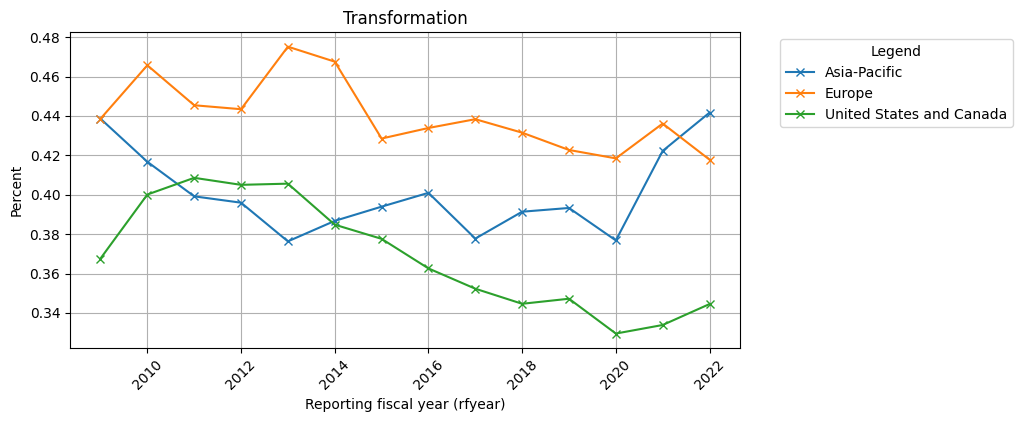

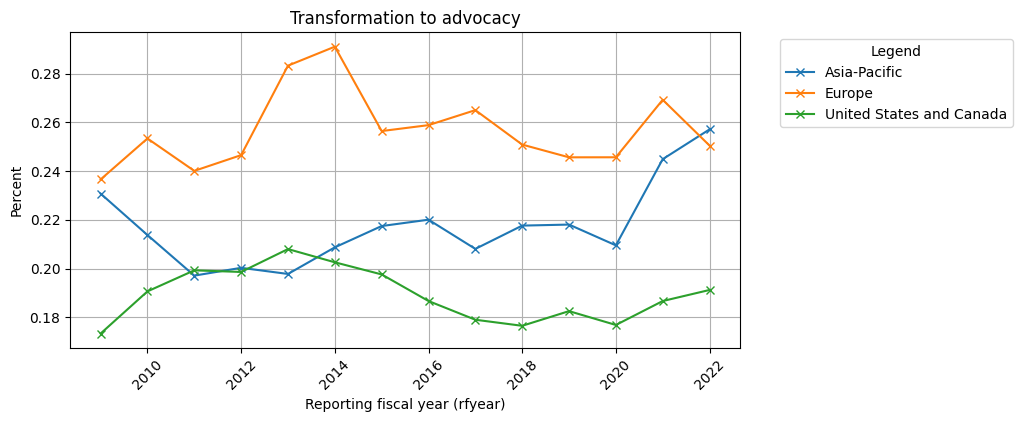

In [ ]:
# =================================================================================
# HEADLINE
# =================================================================================

# Generate aggregate versions of `ratio`
ratio_region_long = lc.groupby(['MacroRegion', 'rfyear'])[[f'sum_with_{max_category}', 'sum_activities']].agg(['sum']).reset_index()
ratio_region_long['ratio'] = ratio_region_long[f'sum_with_{max_category}']/ratio_region_long[f'sum_activities']
ratio_region = pd.pivot(ratio_region_long, index='rfyear', columns='MacroRegion', values='ratio')

# Iterate over each column in the DataFrame to plot
for column in ratio_region.columns:
    plt.plot(ratio_region.index, ratio_region[column], marker='x', linestyle='-', label=column)

plt.title(f'{plt_title_suffix}')
plt.xlabel('Reporting fiscal year (rfyear)')
plt.ylabel('Percent')
plt.grid(True)
plt.xticks(rotation=45)  # Adjust x-axis labels for better readability

# Adjust the legend to be outside the plot
plt.legend(title='Legend', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(rect=[0, 0, 1.6, 0.9])  # Adjust the 'right' parameter to make room for the legend
plt.savefig(f'./img/headline_region.pdf', bbox_inches='tight')  # bbox_inches='tight' helps to ensure all plot elements are included
plt.show()

# =================================================================================
# CORE
# =================================================================================

# Generate aggregate versions of `ratio_max_to_min`
ratio_max_to_min_region_long = lc.groupby(['MacroRegion', 'rfyear'])[[f'sum_with_{min_category}', f'sum_with_{max_category}']].agg(['sum']).reset_index()
ratio_max_to_min_region_long['ratio_max_to_min'] = ratio_max_to_min_region_long[f'sum_with_{max_category}']/ratio_max_to_min_region_long[f'sum_with_{min_category}']
ratio_max_to_min_region = pd.pivot(ratio_max_to_min_region_long, index='rfyear', columns='MacroRegion', values='ratio_max_to_min')

# Iterate over each column in the DataFrame to plot
for column in ratio_max_to_min_region.columns:
    plt.plot(ratio_max_to_min_region.index, ratio_max_to_min_region[column], marker='x', linestyle='-', label=column)

plt.title(f'{plt_max_to_min_title_suffix}')
plt.xlabel('Reporting fiscal year (rfyear)')
plt.ylabel('Percent')
plt.grid(True)
plt.xticks(rotation=45)  # Adjust x-axis labels for better readability

# Adjust the legend to be outside the plot
plt.legend(title='Legend', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(rect=[0, 0, 1.6, 0.9])  # Adjust the 'right' parameter to make room for the legend
plt.savefig(f'./img/core_region.pdf', bbox_inches='tight')  # bbox_inches='tight' helps to ensure all plot elements are included
plt.show()

##### GICS

In [ ]:
# Define a CVD-friendly colour map and line styles
colours = plt.cm.viridis(np.linspace(0, 1, len(lc['Industry'].unique())))
line_styles = ['-', '--', '-.', ':']
markers = ['o', 's', 'D', '^', 'x', '*']

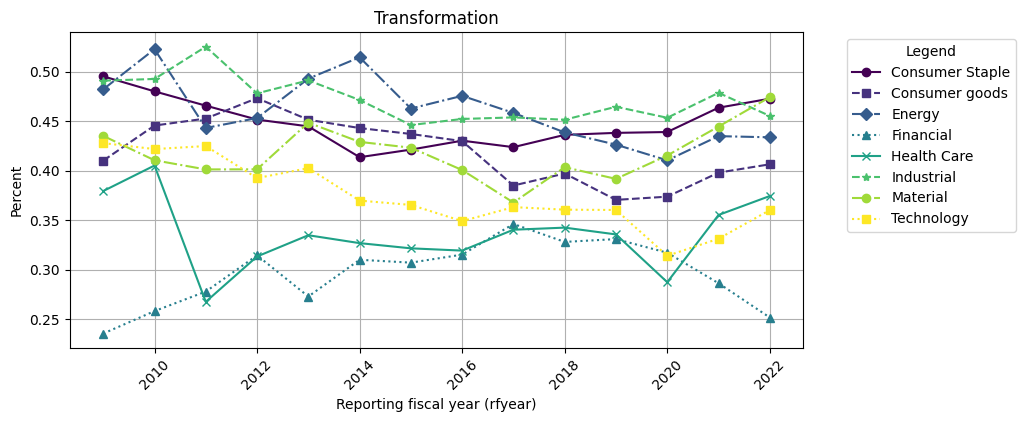

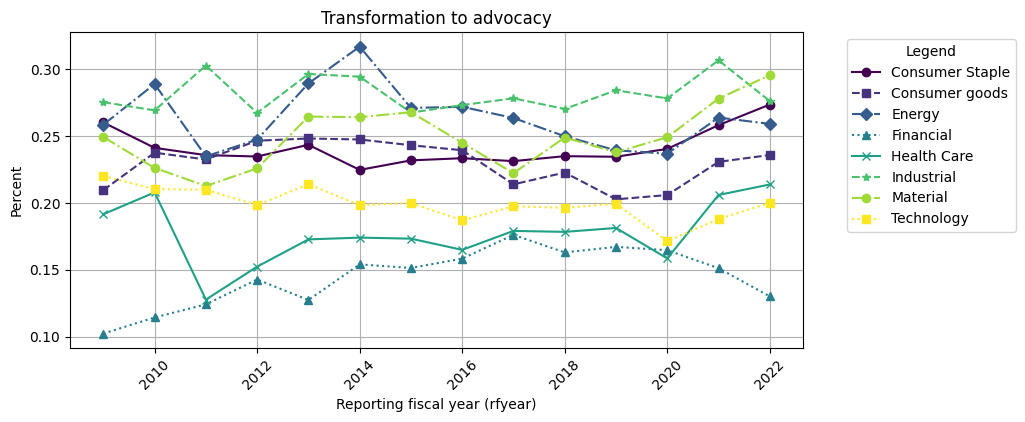

In [ ]:
# =================================================================================
# HEADLINE
# =================================================================================

# Generate aggregate versions of `ratio`
ratio_gics_long = lc.groupby(['Industry', 'rfyear'])[[f'sum_with_{max_category}', 'sum_activities']].agg(['sum']).reset_index()
ratio_gics_long['ratio'] = ratio_gics_long[f'sum_with_{max_category}']/ratio_gics_long[f'sum_activities']
ratio_gics = pd.pivot(ratio_gics_long, index='rfyear', columns='Industry', values='ratio')

# Iterate over each column in the DataFrame to plot
# Plot each column in the DataFrame
for idx, (column, colour) in enumerate(zip(ratio_gics.columns, colours)):
    plt.plot(ratio_gics.index, ratio_gics[column],
                label=column, color=colour,
                linestyle=line_styles[idx % len(line_styles)],
                marker=markers[idx % len(markers)])

plt.title(f'{plt_title_suffix}')
plt.xlabel('Reporting fiscal year (rfyear)')
plt.ylabel('Percent')
plt.grid(True)
plt.xticks(rotation=45)  # Adjust x-axis labels for better readability

# Adjust the legend to be outside the plot
plt.legend(title='Legend', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(rect=[0, 0, 1.6, 0.9])  # Adjust the 'right' parameter to make room for the legend
plt.savefig(f'./img/headline_gics.pdf', bbox_inches='tight')  # bbox_inches='tight' helps to ensure all plot elements are included
plt.show()

# =================================================================================
# CORE
# =================================================================================

# Generate aggregate versions of `ratio_max_to_min`
ratio_max_to_min_gics_long = lc.groupby(['Industry', 'rfyear'])[[f'sum_with_{min_category}', f'sum_with_{max_category}']].agg(['sum']).reset_index()
ratio_max_to_min_gics_long['ratio_max_to_min'] = ratio_max_to_min_gics_long[f'sum_with_{max_category}']/ratio_max_to_min_gics_long[f'sum_with_{min_category}']
ratio_max_to_min_gics = pd.pivot(ratio_max_to_min_gics_long, index='rfyear', columns='Industry', values='ratio_max_to_min')

# Iterate over each column in the DataFrame to plot
for idx, (column, colour) in enumerate(zip(ratio_max_to_min_gics.columns, colours)):
    plt.plot(ratio_max_to_min_gics.index, ratio_max_to_min_gics[column],
                label=column, color=colour,
                linestyle=line_styles[idx % len(line_styles)],
                marker=markers[idx % len(markers)])

plt.title(f'{plt_max_to_min_title_suffix}')
plt.xlabel('Reporting fiscal year (rfyear)')
plt.ylabel('Percent')
plt.grid(True)
plt.xticks(rotation=45)  # Adjust x-axis labels for better readability

# Adjust the legend to be outside the plot
plt.legend(title='Legend', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(rect=[0, 0, 1.6, 0.9])  # Adjust the 'right' parameter to make room for the legend
plt.savefig(f'./img/core_gics.pdf', bbox_inches='tight')  # bbox_inches='tight' helps to ensure all plot elements are included
plt.show()

In [ ]:
from matplotlib.cm import get_cmap

# Plotting data
global_gross_portfolio_returns = pd.DataFrame()
global_gross_portfolio_returns.index                   = global_returns.index
global_gross_portfolio_returns['Market']               = 1+global_returns.mean(axis=1)
global_gross_portfolio_returns['Low advocacy']      = 1+signal_0_simple_quantiles[f'p_1']
global_gross_portfolio_returns['High org transf']        = 1+signal_2_simple_quantiles[f'p_{no_simple_quantiles}']
global_gross_portfolio_returns['High combined signal'] = 1+combined_signal_max_min_simple_quantiles[f'p_{no_simple_quantiles}']

# Compute the cumulative product starting from 1
cumulative_products = global_gross_portfolio_returns.cumprod()

# Plotting
fig, ax = plt.subplots()
cmap = get_cmap('viridis')
colors = cmap(np.linspace(0, 1, len(global_gross_portfolio_returns.columns)))
line_styles = ['-', '--', '-.', ':', (0, (3, 5, 1, 5))]

for i, col in enumerate(cumulative_products.columns):
    ax.plot(cumulative_products.index, cumulative_products[col], label=col, color=colors[i], linestyle=line_styles[i])

ax.set_xlabel('Date')
ax.set_ylabel('US Dollars')

# Adjust the legend to be outside the plot
plt.legend(title='Legend', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(rect=[0, 0, 1.6, 0.9])  # Adjust the 'right' parameter to make room for the legend
plt.savefig(f'./img/cumulative_returns_p_3.pdf', bbox_inches='tight')  # bbox_inches='tight' helps to ensure all plot elements are included
plt.show()

NameError: name 'global_returns' is not defined

### 5. Fama-french regressions

In [ ]:
# Load relevant dependencies
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [ ]:
def ff3_regressions(excess_returns, fama_french):

    # Memory pre-allocation for output
    ff3_regressions = pd.DataFrame(np.zeros((9, excess_returns.shape[1])))
    ff3_regressions.columns = excess_returns.columns

    # Gather FF3 factors
    independent_data = fama_french[['mktrf', 'smb', 'hml']]

    for (i, col) in enumerate(excess_returns.columns):

        # Gather dependent data
        dependent_data = pd.Series(excess_returns[col].values, name="excrt")

        # Merge variables
        ols_data = 100*pd.concat(
            [
                dependent_data,
                independent_data
            ], axis=1
        )

        # Skip missings
        ols_data = ols_data[ols_data.notna().all(axis=1)].reset_index(drop=True)

        # Model
        mod = smf.ols(formula='excrt ~ mktrf + smb + hml', data=ols_data)
        
        # Estimate and show output
        fitted_model = mod.fit(cov_type='HC1')

        # Get regression results
        fitted_model_summary = fitted_model.summary2().tables[1]

        # Populate `ff3_regressions`
        ff3_regressions.iloc[0:4, i] = fitted_model_summary["Coef."].values
        ff3_regressions.iloc[4:8, i] = fitted_model_summary["P>|z|"].values
        ff3_regressions.iloc[8, i] = fitted_model.rsquared_adj

    # Return regression output
    return ff3_regressions

# Function to calculate max drawdown
def risk(column):

    # Calculate cumulative maximum
    cum_max = column.cummax()

    # Calculate drawdown
    return 100*(column/cum_max - 1).min()    

In [ ]:
# Excess returns based on signal_0
signal_0_excess_returns = signal_0_simple_quantiles.sub(fama_french['rf'].values, axis=0)

# Excess returns based on signal_1
signal_1_excess_returns = signal_1_simple_quantiles.sub(fama_french['rf'].values, axis=0)

# Excess returns based on signal_2
signal_2_excess_returns = signal_2_simple_quantiles.sub(fama_french['rf'].values, axis=0)

# Excess returns based on combined_signal_max_min
combined_signal_max_min_excess_returns = combined_signal_max_min_simple_quantiles.sub(fama_french['rf'].values, axis=0)

NameError: name 'signal_0_simple_quantiles' is not defined

In [ ]:
# Table on FF3
pd.concat(
    [
        ff3_regressions(signal_0_excess_returns, fama_french), 
        ff3_regressions(signal_1_excess_returns, fama_french), 
        ff3_regressions(signal_2_excess_returns, fama_french), 
        ff3_regressions(combined_signal_max_min_excess_returns, fama_french), 
    ], axis=1
).to_csv('./tables/ff3.csv')

# Table on downside risk
pd.concat(
    [
        risk((1+signal_0_simple_quantiles).cumprod()), 
        risk((1+signal_1_simple_quantiles).cumprod()), 
        risk((1+signal_2_simple_quantiles).cumprod()), 
        risk((1+combined_signal_max_min_simple_quantiles).cumprod()), 
        risk(pd.DataFrame(1+global_returns.mean(axis=1)).cumprod())
    ], axis=0
).to_csv('./tables/risk.csv')

### 6 Sector and macroreg comparisons

In [ ]:
lc_sector_country = lc[['gvkey', 'Industry', 'MacroRegion','signal_0', 'signal_1', 'signal_2']].drop_duplicates().copy()
lc_sector_country['signal_combined'] = lc_sector_country['signal_2'] - lc_sector_country['signal_0']

# Get signals over time with sector and country information
dt = global_universe_yearly[['gvkey_iid', 'year']].copy()

dt['gvkey'] = dt['gvkey_iid'].map(lambda x: x.split('_')[0])
dt = dt.drop(columns='gvkey_iid').drop_duplicates()
dt = pd.merge(dt, lc_sector_country, on='gvkey', how='left')
dt

In [ ]:
# plot signals over time across sectors
signals = ['signal_0', 'signal_1', 'signal_2', 'signal_combined']
fig, ax = plt.subplots(len(signals), 1, figsize=(10, 6*len(signals)))
cmap = get_cmap('viridis')
colors = cmap(np.linspace(0, 1, len(dt['Industry'].unique())))
line_styles = ['-', '--', '-.', ':', (0, (3, 5, 1, 5))]
markers = ['o', 's', 'D', '^', 'x', '*']

for idx, (column, colour) in enumerate(zip(dt['Industry'].unique(), colors)):
    for signal in signals:
        ax[signals.index(signal)].plot(
            dt[dt['Industry'] == column].groupby('year')[signal].mean(),
            label=column, color=colour,
            linestyle=line_styles[idx % len(line_styles)],
            marker=markers[idx % len(markers)],
        )

        ax[signals.index(signal)].set_title(f'{signal} over time across sectors')
        ax[signals.index(signal)].set_xlabel('Year')
        ax[signals.index(signal)].set_ylabel('Signal')
        ax[signals.index(signal)].grid(True)
        ax[signals.index(signal)].legend(title='Sector', bbox_to_anchor=(1.05, 1), loc='upper left')


In [ ]:
# plot signals over time across countries
signals = ['signal_0', 'signal_1', 'signal_2', 'signal_combined']
fig, ax = plt.subplots(len(signals), 1, figsize=(10, 6*len(signals)))
cmap = get_cmap('viridis')
colors = cmap(np.linspace(0, 1, len(dt['MacroRegion'].unique())))
line_styles = ['-', '--', '-.', ':', (0, (3, 5, 1, 5))]
markers = ['o', 's', 'D', '^', 'x', '*']

for idx, (column, colour) in enumerate(zip(dt['MacroRegion'].unique(), colors)):
    for signal in signals:
        ax[signals.index(signal)].plot(
            dt[dt['MacroRegion'] == column].groupby('year')[signal].mean(),
            label=column, color=colour,
            linestyle=line_styles[idx % len(line_styles)],
            marker=markers[idx % len(markers)],
        )

        ax[signals.index(signal)].set_title(f'{signal} over time across countries')
        ax[signals.index(signal)].set_xlabel('Year')
        ax[signals.index(signal)].set_ylabel('Signal')
        ax[signals.index(signal)].grid(True)
        ax[signals.index(signal)].legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')

